**DATA CLEANING**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


One-Hot Encoding

In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
print(f"  Duplicate rows     : {df.duplicated().sum()}")
print(f"  Missing values     : {df.isnull().sum().sum()}")

  Duplicate rows     : 1081
  Missing values     : 0


In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [11]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

**OBSERVATION**

Total transactions: 284,807

Total features:31

Missing values=0

Target variable->'Class'

Most features (V1–V28) are anonymized using PCA.The dataset is highly imbalanced, with very few fraudulent transactions compared to normal ones.

The 'Class' feature represents the transaction label:

0 → Normal transaction
1 → Fraudulent transaction

A significant class imbalance is observed, where fraudulent transactions are extremely rare compared to normal transactions. This imbalance is a critical factor to consider during model building, as it can affect the performance of standard classification algorithms

**DATA PREPROCESSING**

1.Feature Scaling(Normalisation)

2.Drop Unnecessary Column

3.Handle Imbalanced Data

4.Feature Engineering

5.Feature Standardization¶


In [12]:
# feature scaling (normalization)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale the 'Amount' column
# fit_transform() computes mean & std, then standardizes values
# Formula: (value - mean) / standard deviation
df['Amount'] = scaler.fit_transform(df[['Amount']])

# Drop the 'Time' column as it is not useful for prediction
df=df.drop(columns=["Time"])

from imblearn.over_sampling import SMOTE

X = df.drop('Class', axis=1)   
y = df['Class']
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

Reason New features are created to improve the performance of the model.

The 'Hour' feature helps in identifying time-based patterns in transactions.

The 'Log_Amount' feature reduces skewness in transaction values and makes the distribution more normalized.

The 'High_Amount' feature helps in identifying unusually large transactions which may be more likely to be fraudulent.

In [13]:
# # -- Feature Standardization -- 
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# # Features jo scale karni hain
# features_to_scale = ['Hour', 'Log_Amount']

# df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# df[features_to_scale].head()

Reason Standardization is applied to ensure that features are on the same scale.

This helps machine learning models perform better and converge faster, especially for algorithms sensitive to feature magnitude.

Save Preprocessed Dataset

In [14]:
df.to_csv("preprocessed_creditcard.csv", index=False)

**VISUAL ANALYTICS**

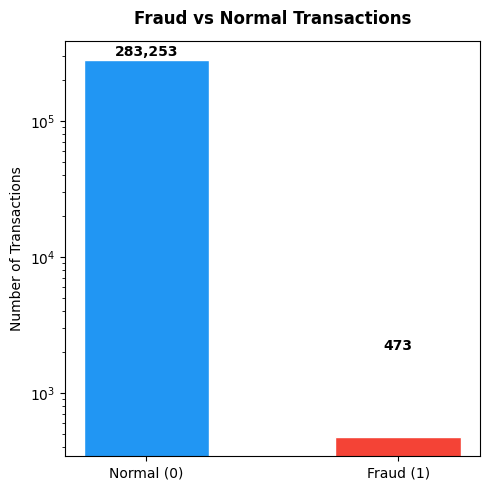

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
class_counts = df['Class'].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(["Normal (0)", "Fraud (1)"], class_counts.values,
              color=["#2196F3", "#F44336"], edgecolor="white", width=0.5)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
            f"{val:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Fraud vs Normal Transactions", fontweight="bold",pad=12)
ax.set_ylabel("Number of Transactions")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=130)
plt.show()

This means fraudulent transactions make up less than 0.2% of the total data, while the vast majority are normal.

->The dataset is highly skewed toward normal transactions

->Standard machine learning models may become biased toward predicting normal cases.

->Special techniques like resampling (SMOTE/undersampling) or anomaly detection methods may be required to effectively detect fraud

In [16]:
sns.set(style="whitegrid")

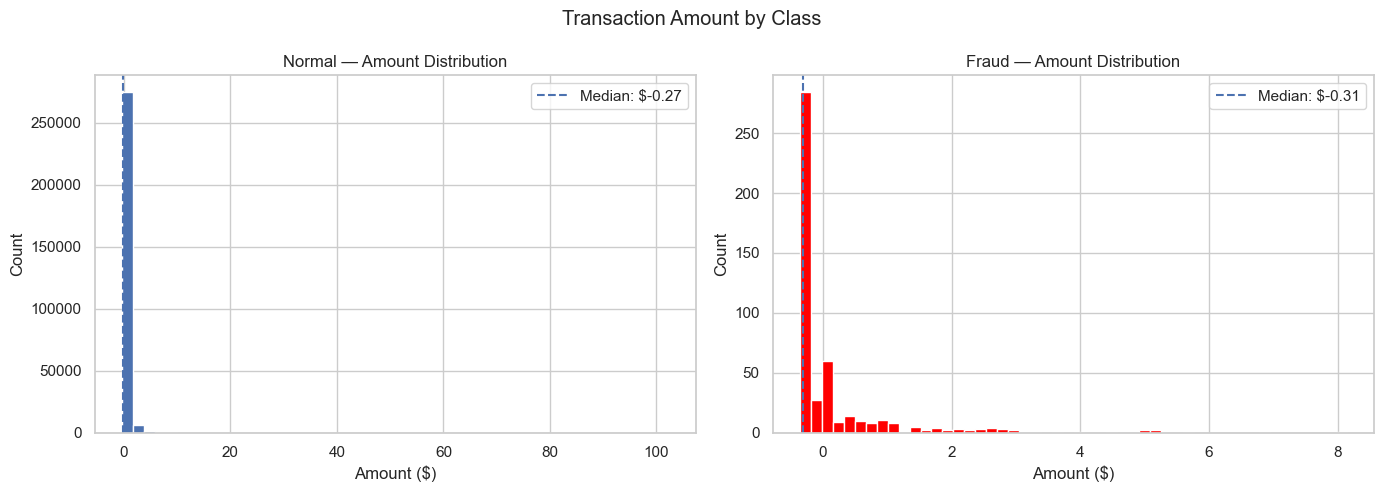

In [17]:
# Separate data
normal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------- Normal Transactions --------
axes[0].hist(normal['Amount'], bins=50)
axes[0].set_title("Normal — Amount Distribution")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Count")

# Median line
median_normal = normal['Amount'].median()
axes[0].axvline(median_normal, linestyle='--')
axes[0].legend([f"Median: ${median_normal:.2f}"])

# -------- Fraud Transactions --------
axes[1].hist(fraud['Amount'], bins=50,color="red")
axes[1].set_title("Fraud — Amount Distribution")
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Count")

# Median line
median_fraud = fraud['Amount'].median()
axes[1].axvline(median_fraud, linestyle='--')
axes[1].legend([f"Median: ${median_fraud:.2f}"])

# Main title
plt.suptitle("Transaction Amount by Class")

plt.tight_layout()
plt.show()

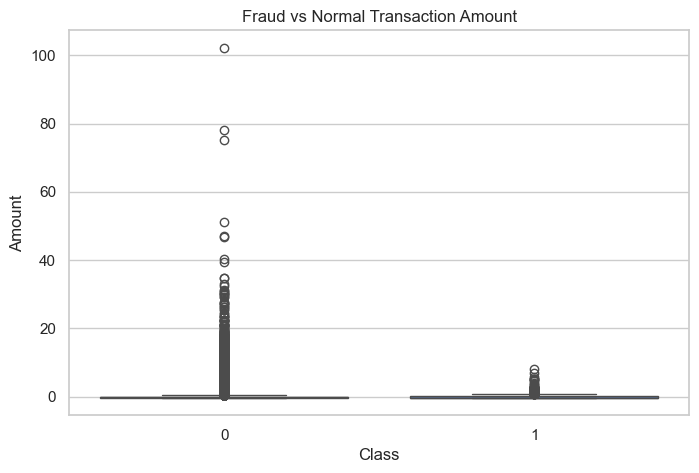

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Normal Transaction Amount")
plt.show()

Transaction activity is distributed across time but shows periodic patterns, indicating daily cycles. Fraudulent transactions do not follow a clear pattern and are scattered, making them harder to detect using time alone.

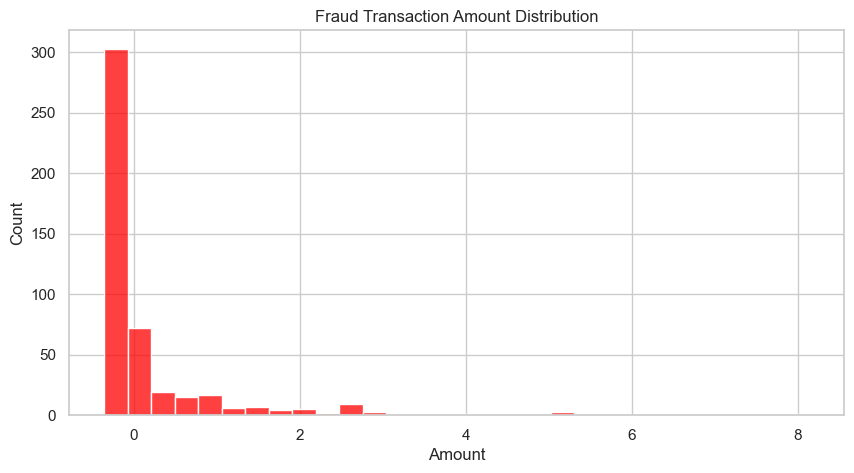

In [20]:
fraud = df[df['Class'] == 1]

plt.figure(figsize=(10,5))
sns.histplot(fraud['Amount'], bins=30, color='red')
plt.title("Fraud Transaction Amount Distribution")
plt.show()

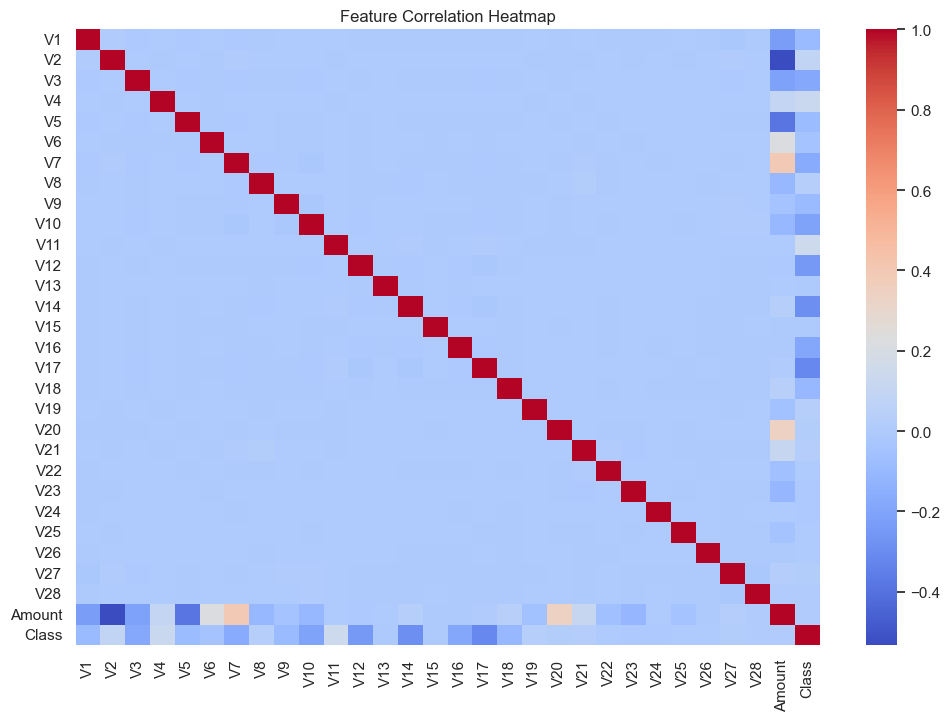

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Observation:
Most features show low correlation with each other, indicating independence due to PCA transformation. However, a few features may show slight correlation with the target variable (Class), which can be useful for fraud detection.

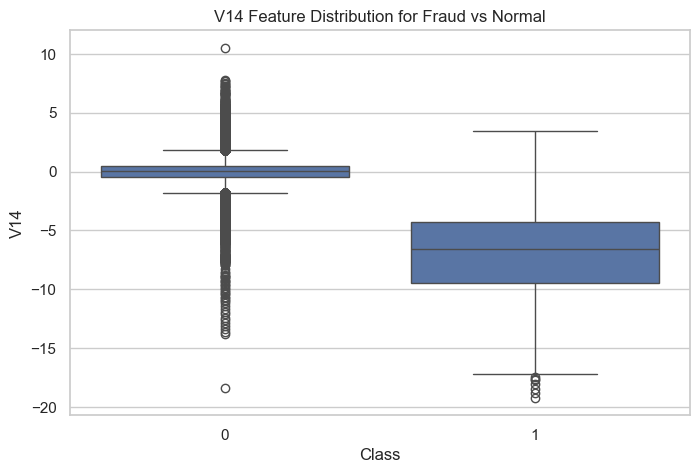

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='V14', data=df)
plt.title("V14 Feature Distribution for Fraud vs Normal")
plt.show()

Observation:
Fraudulent transactions generally have lower median amounts compared to normal transactions, but there is overlap. This indicates that amount alone is not sufficient to detect fraud.

In [23]:
fraud_count = df['Class'].value_counts()[1]
normal_count = df['Class'].value_counts()[0]

fraud_percentage = (fraud_count / len(df)) * 100

print("Fraud Transactions:", fraud_count)
print("Normal Transactions:", normal_count)
print("Fraud Percentage:", fraud_percentage)

Fraud Transactions: 473
Normal Transactions: 283253
Fraud Percentage: 0.1667101358352777


**Feature Selection**

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# Count class distribution (TRAIN)
normal_train = (y_train == 0).sum()
fraud_train = (y_train == 1).sum()

# Count class distribution (TEST)
normal_test = (y_test == 0).sum()
fraud_test = (y_test == 1).sum()

print("----- TRAIN SET -----")
print(f"Total rows: {len(X_train):,}")
print(f"Normal transactions: {normal_train:,}")
print(f"Fraud transactions : {fraud_train:,}")
print(f"Fraud %: {y_train.mean()*100:.3f}%")

print("\n----- TEST SET -----")
print(f"Total rows: {len(X_test):,}")
print(f"Normal transactions: {normal_test:,}")
print(f"Fraud transactions : {fraud_test:,}")
print(f"Fraud %: {y_test.mean()*100:.3f}%")


----- TRAIN SET -----
Total rows: 226,980
Normal transactions: 226,602
Fraud transactions : 378
Fraud %: 0.167%

----- TEST SET -----
Total rows: 56,746
Normal transactions: 56,651
Fraud transactions : 95
Fraud %: 0.167%


**FEATURE IMPORTATION ANALYSIS**

->Finding which features are most useful to detect fraud
👉 Model becomes faster + more accurate

MODELS USED:

1. Random Forest

→ Importance is based on how much each feature reduces impurity (Gini) across multiple trees

2. Logistic Regression

→ Importance is based on magnitude of coefficients (weights) assigned to each feature

3. Decision Tree

→ Importance is based on how well a feature splits the data to reduce impurity

4. Extra Trees Classifier

→ Importance is based on randomized splits across many trees to measure feature contribution

5. LightGBM

→ Importance is based on how frequently and effectively features are used in sequential boosting trees

In [26]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier

# -------------------------------
# Function to display importance
# -------------------------------
def display_importance(model_name, feature_names, importances):
    df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print(f"\n{'='*50}")
    print(f"{model_name} - TOP 10 FEATURES")
    print(f"{'='*50}")
    print(df.head(10).to_string(index=False))

# -------------------------------
# 1. RANDOM FOREST
# -------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

display_importance(
    "Random Forest",
    X.columns,
    rf.feature_importances_
)

# -------------------------------
# 2. LOGISTIC REGRESSION
# -------------------------------
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)

display_importance(
    "Logistic Regression",
    X.columns,
    np.abs(lr.coef_[0])
)

# -------------------------------
# 3. DECISION TREE
# -------------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

display_importance(
    "Decision Tree",
    X.columns,
    dt.feature_importances_
)

# -------------------------------
# 4. EXTRA TREES
# -------------------------------
et = ExtraTreesClassifier(n_estimators=100, random_state=42)
et.fit(X_train, y_train)

display_importance(
    "Extra Trees",
    X.columns,
    et.feature_importances_
)

# -------------------------------
# 5. LIGHTGBM
# -------------------------------
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)

display_importance(
    "LightGBM",
    X.columns,
    lgb.feature_importances_
)


Random Forest - TOP 10 FEATURES
Feature  Importance
    V17    0.138879
    V12    0.121731
    V14    0.116392
    V10    0.088992
    V16    0.084128
    V11    0.080541
     V9    0.041852
    V18    0.031213
     V4    0.029242
     V7    0.028687

Logistic Regression - TOP 10 FEATURES
Feature  Importance
    V14    0.684347
    V10    0.676428
     V4    0.614934
    V22    0.577649
    V27    0.405123
    V21    0.328487
    V16    0.309687
    V13    0.260314
    V20    0.250053
     V8    0.214888

Decision Tree - TOP 10 FEATURES
Feature  Importance
    V17    0.532432
    V14    0.093275
    V10    0.083939
    V26    0.041204
    V21    0.022498
     V6    0.021857
     V7    0.020690
    V16    0.020331
     V1    0.017983
     V4    0.017443

Extra Trees - TOP 10 FEATURES
Feature  Importance
    V17    0.137651
    V14    0.135189
    V12    0.099713
    V10    0.077961
    V16    0.074065
    V11    0.059858
    V18    0.042134
     V4    0.039237
     V3    0.035521
    

**FINAL OBSERVATION**

 Feature importance was evaluated using multiple models. It was observed that features such as V14, V17, V12, and V10 consistently appeared among the top features, indicating their strong contribution in detecting fraudulent transactions.

In [27]:
top_features = rf.feature_importances_.argsort()[-10:]
X_top = X.iloc[:, top_features]
X_top

,V7,V4,V18,V9,V11,V16,V10,V14,V12,V17
0,0.239599,1.378155,0.025791,0.363787,-0.551600,-0.470401,0.090794,-0.311169,-0.617801,0.207971
1,-0.078803,0.448154,-0.183361,-0.255425,1.612727,0.463917,-0.166974,-0.143772,1.065235,-0.114805
2,0.791461,0.379780,-0.121359,-1.514654,0.624501,-2.890083,0.207643,-0.165946,0.066084,1.109969
3,0.237609,-0.863291,1.965775,-1.387024,-0.226487,-1.059647,-0.054952,-0.287924,0.178228,-0.684093
4,0.592941,0.403034,-0.038195,0.817739,-0.822843,-0.451449,0.753074,-1.119670,0.538196,-0.237033
...,...,...,...,...,...,...,...,...,...,...
284802,-4.918215,-2.066656,0.510632,1.914428,-1.593105,1.107641,4.356170,4.626942,2.711941,1.991691
284803,0.024330,-0.738589,-1.221179,0.584800,-0.150189,-0.711757,-0.975926,-0.675143,0.915802,-0.025693
284804,-0.296827,-0.557828,0.395652,0.432454,0.411614,0.140716,-0.484782,-0.510602,0.063119,0.313502
284805,-0.686180,0.689799,1.113981,0.392087,-1.933849,-0.608577,-0.399126,0.449624,-0.962886,0.509928


**MODEL TRAINING**

In [28]:
# 📦 IMPORT LIBRARIES
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [29]:
# 🤖 DEFINE MODELS 

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight='balanced'
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=150,
        max_depth=10,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=10,   # handles imbalance
        eval_metric='logloss',
        use_label_encoder=False
    )
}

# 🏋️ TRAIN MODELS
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print(" All models trained successfully!")

C:\Users\Varshitha\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [20:28:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 All models trained successfully!


In [30]:
# 📊 MODEL EVALUATION FUNCTION

def evaluate_model(name, model):
    
    print("\n" + "="*60)
    print(f"🚀 MODEL: {name}")
    print("="*60)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Confusion Matrix
    print("\n🔹 Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Classification Report
    print("\n🔹 Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # ROC-AUC
    auc = roc_auc_score(y_test, y_prob)
    print(f"🎯 ROC-AUC Score: {auc:.4f}")
    
    return {
        "Model": name,
        "Recall": classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        "Precision": classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        "F1": classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
        "AUC": auc
    }

# 📈 RUN EVALUATION FOR ALL MODELS

results = []

for name, model in trained_models.items():
    result = evaluate_model(name, model)
    results.append(result)


🚀 MODEL: Logistic Regression

🔹 Confusion Matrix:
[[55245  1406]
 [   12    83]]

🔹 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.10        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

🎯 ROC-AUC Score: 0.9647

🚀 MODEL: Decision Tree

🔹 Confusion Matrix:
[[56642     9]
 [   28    67]]

🔹 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.71      0.78        95

    accuracy                           1.00     56746
   macro avg       0.94      0.85      0.89     56746
weighted avg       1.00      1.00      1.00     56746

🎯 ROC-AUC Score: 0.8746

🚀 MODEL: Random Forest

🔹 Confusion Matrix:
[[56642     9]
 [   25    70]]

🔹 Classific

## Metric Glossary

| Metric    | What it measures                                      | Why it matters for fraud                         |
|----------|------------------------------------------------------|------------------------------------------------|
| Accuracy | Overall correct predictions                          | Misleading — included for reference only        |
| Precision| Of predicted frauds, how many were real?             | Controls false alarms                           |
| Recall   | Of real frauds, how many did we catch?               | Most critical — missed fraud = loss             |
| F1       | Harmonic mean of precision & recall                  | Single balanced score                           |
| ROC-AUC  | Area under ROC curve                                 | Good ranking metric                             |
| PR-AUC   | Area under Precision-Recall curve                    | Best for imbalanced data                        |
| MCC      | Matthews Correlation Coefficient                     | Balanced even with extreme class sizes          |

**MODEL COMPARISON**

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, average_precision_score

comparison_results = []

for name, model in trained_models.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Set index
comparison_df.set_index("Model", inplace=True)

# Round values
comparison_df = comparison_df.round(6)

comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
Model,,,,,,,
Logistic Regression,0.975011,0.055742,0.873684,0.104798,0.964671,0.673566,0.217102
Decision Tree,0.999348,0.881579,0.705263,0.783626,0.874627,0.617847,0.788198
Random Forest,0.999401,0.886076,0.736842,0.804598,0.969560,0.766390,0.807733
Extra Trees,0.999295,0.982456,0.589474,0.736842,0.969116,0.780607,0.760729
XGBoost,0.999507,0.935065,0.757895,0.837209,0.972319,0.809751,0.841600


**MODELS VISUAL COMPARISION**

In [32]:
from sklearn.metrics import (
    roc_auc_score, f1_score,
    precision_score, recall_score,
    matthews_corrcoef, average_precision_score
)

results = []

for name, model in trained_models.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results.append({
        "Model": name,
        "_y_pred": y_pred,
        "_y_proba": y_prob,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "F1": f1,
        "Recall": recall,
        "Precision": precision,
        "MCC": mcc
    })

ALL MODELS ROC-CURVE

NameError: name 'roc_curve' is not defined

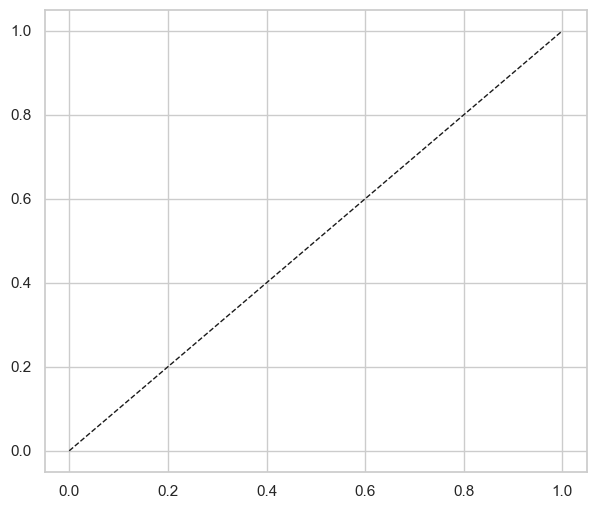

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))

# Random baseline
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.50)")

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["_y_proba"])
    ax.plot(fpr, tpr, lw=2,
            color=PALETTE[r["Model"]],
            label=f"{r['Model']} (AUC = {r['ROC-AUC']:.4f})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves — All Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=130)
plt.show()

The ROC curve analysis shows that all models perform well with high AUC values. Among them, XGBoost achieves the highest ROC-AUC score, indicating superior ability to distinguish between fraudulent and normal transactions.

ALL MODELS PRECISION-RECALL CURVE

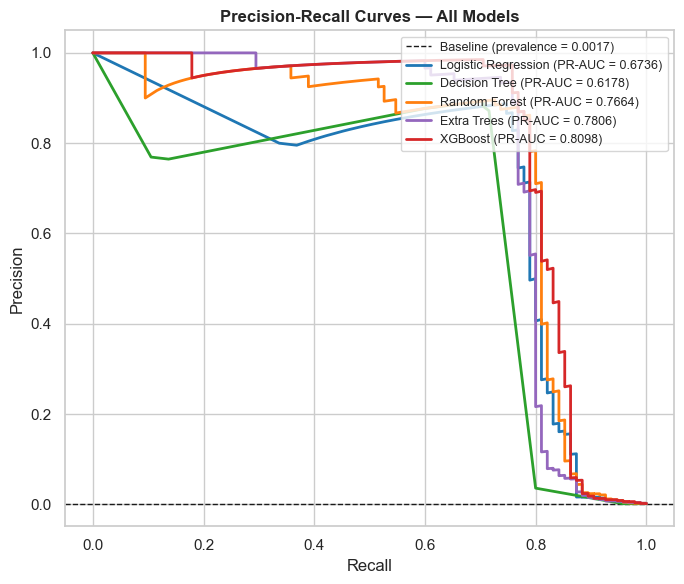

In [ ]:
prevalence = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 6))

# Baseline
ax.axhline(prevalence, color="k", linestyle="--", lw=1,
           label=f"Baseline (prevalence = {prevalence:.4f})")

for r in results:
    prec, rec, _ = precision_recall_curve(y_test, r["_y_proba"])
    
    ax.plot(rec, prec, lw=2,
            color=PALETTE[r["Model"]],
            label=f"{r['Model']} (PR-AUC = {r['PR-AUC']:.4f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("pr_curves.png", dpi=130)
plt.show()

The Precision-Recall curve demonstrates that XGBoost maintains a better balance between precision and recall compared to other models. This is particularly important for imbalanced datasets, where detecting fraud accurately while minimizing false positives is critical.

METRICS COMPARISION BAR CHART

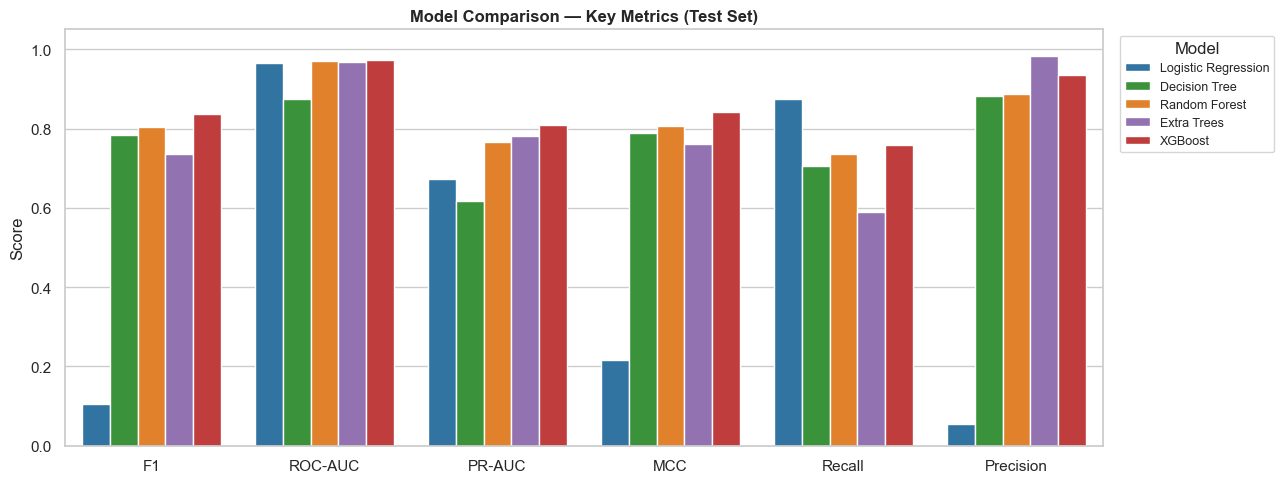

In [ ]:
# Convert results to DataFrame
summary_df = pd.DataFrame(results).set_index("Model")

metrics_to_plot = ["F1", "ROC-AUC", "PR-AUC", "MCC", "Recall", "Precision"]

df_melted = (summary_df[metrics_to_plot]
             .reset_index()
             .melt(id_vars="Model", var_name="Metric", value_name="Score"))

fig, ax = plt.subplots(figsize=(13, 5))

sns.barplot(data=df_melted,
            x="Metric", y="Score",
            hue="Model",
            palette=PALETTE,
            ax=ax)

ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison — Key Metrics (Test Set)", fontweight="bold")
ax.set_xlabel("")

ax.legend(title="Model",
          bbox_to_anchor=(1.01, 1),
          loc="upper left",
          fontsize=9)

plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=130)
plt.show()

The comparison of evaluation metrics shows that different models perform differently across metrics. Some models prioritize recall, while others achieve better precision or F1-score, demonstrating the importance of selecting a model based on the problem requirement.

NORMALISED CONFUSION MATRICES

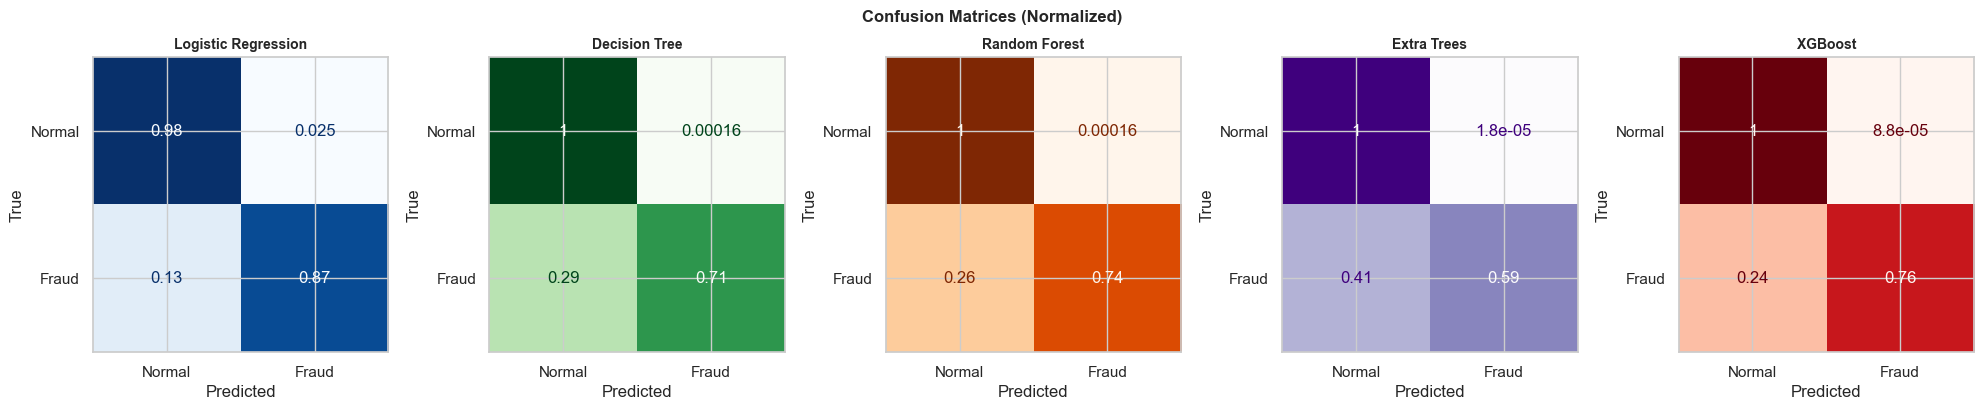

In [ ]:
n = len(results)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

cmaps = ["Blues", "Greens", "Oranges", "Purples", "Reds"]

fig.suptitle("Confusion Matrices (Normalized)",
             fontweight="bold", fontsize=12)

for ax, r, cmap in zip(axes, results, cmaps):
    
    cm = confusion_matrix(y_test, r["_y_pred"], normalize="true")
    
    disp = ConfusionMatrixDisplay(cm,
                                 display_labels=["Normal", "Fraud"])
    
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    
    ax.set_title(r["Model"], fontweight="bold", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=130)
plt.show()

The confusion matrices reveal how each model handles classification errors. While most models correctly classify the majority of normal transactions, there is variation in how effectively they detect fraudulent cases and minimize misclassification.

**CONCLUSION FROM VISUALS**

The visual analysis shows that no single metric is sufficient to evaluate model performance. A balanced approach considering recall, precision, and overall classification ability is essential for effective fraud detection.

**MODEL SELECTION**

In [ ]:
# Select best model based on F1 + Recall
best_model = comparison_df.sort_values(by=["F1", "Recall"], ascending=False).index[0]

print("🏆 Best Model:", best_model)

🏆 Best Model: XGBoost


▶ Logistic Regression achieved the highest recall but had a low F1-score, indicating poor precision.

▶ XGBoost provided the best balance between recall and precision acheiving highest F1-score and ROC-AUC among all models.

▶ “The best model is selected based on recall and F1-score. XGBoost performed best by balancing fraud detection and false positives.”

**XGBOOST MODEL TRAINING**

In [ ]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=20, # Zandles imbalance
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:,1]
y_pred_new = (y_prob > 0.3).astype(int)

C:\Users\Varshitha\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [00:02:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**XGBOOST CLASSIFICATION REPORT**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\n🔹 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n🔹 Classification Report:")
print(classification_report(y_test, y_pred))

print(f"\n🎯 ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")


🔹 Confusion Matrix:
[[56646     5]
 [   23    72]]

🔹 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.76      0.84        95

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746


🎯 ROC-AUC Score: 0.9738


**CONCLUSION**

✔ The XGBoost model demonstrated strong performance in detecting fraudulent transactions, achieving a high precision of 0.94, recall of 0.76, and an F1-score of 0.84.

✔ The ROC-AUC score of 0.9723 indicates excellent classification capability.

✔ Although a few fraud cases were missed, the model maintains a good balance between detecting fraud and minimizing false alarms.

✔ Therefore, the model is effective and suitable for real-world fraud detection scenarios.

**ROC-Curve**

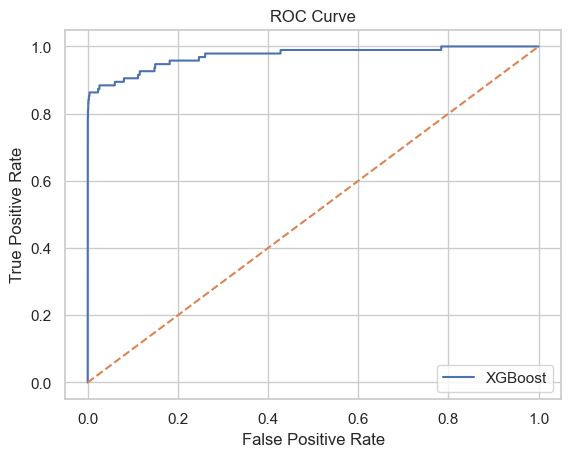

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**PRECISION-RECALL CURVE**

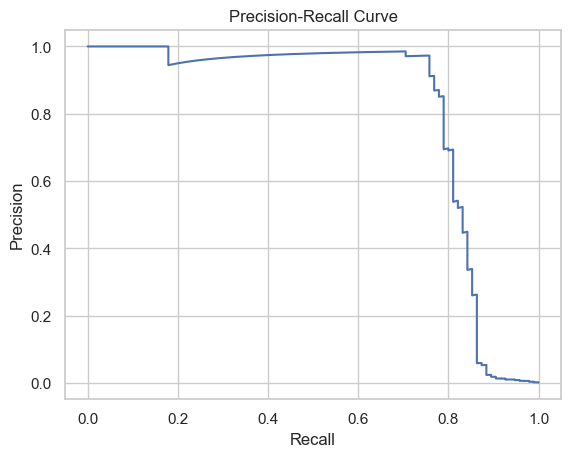

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**XGBOOST FEATURE IMPORTANCE GRAPH**

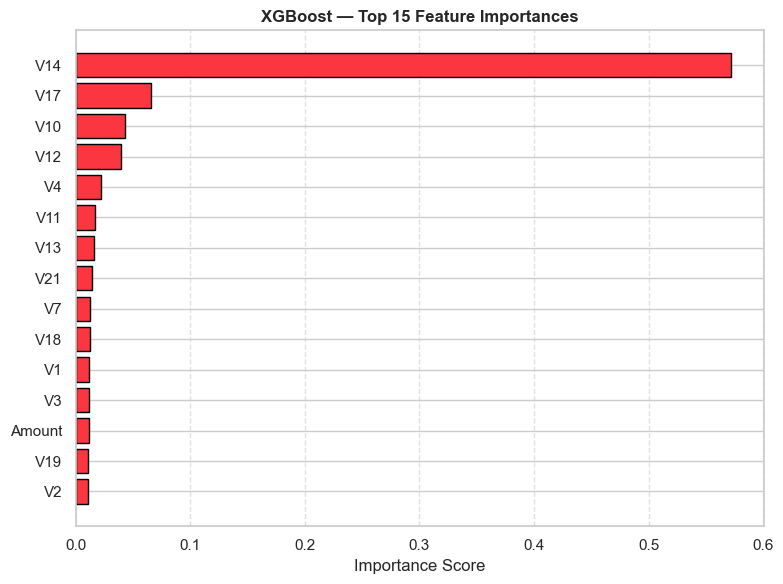

In [ ]:
xgb_model = models["XGBoost"]

# Get feature names
feature_names = X.columns

# Get importance scores
# ✔ Normalized
# ✔ Scaled between 0–1
importances = xgb_model.feature_importances_

# Select top N features
top_n = 15
indices = np.argsort(importances)[-top_n:]

# Sort them for better visualization
indices = indices[np.argsort(importances[indices])]
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(range(top_n),
        importances[indices],
        color="#fb3640",
        edgecolor="black")

ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in indices])

ax.set_title(f"XGBoost — Top {top_n} Feature Importances",
             fontweight="bold")

ax.set_xlabel("Importance Score")

ax.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("feature_importance_xgb.png", dpi=130)
plt.show()

The model primarily depends on a few important features for fraud detection, while other features have minimal impact..

In [ ]:
xgb_model.get_booster().get_score(importance_type='gain')
# Represents total gain (actual contribution)
# NOT normalized

{'V1': 8.731307983398438,
 'V2': 7.83717679977417,
 'V3': 8.1903715133667,
 'V4': 15.989891052246094,
 'V5': 7.355020523071289,
 'V6': 4.882107734680176,
 'V7': 8.906946182250977,
 'V8': 7.643705368041992,
 'V9': 5.287250995635986,
 'V10': 31.22861671447754,
 'V11': 11.965627670288086,
 'V12': 28.898983001708984,
 'V13': 11.512048721313477,
 'V14': 412.72607421875,
 'V15': 7.587898254394531,
 'V16': 7.792868137359619,
 'V17': 47.46638107299805,
 'V18': 8.861435890197754,
 'V19': 7.9081621170043945,
 'V20': 6.737075328826904,
 'V21': 10.570574760437012,
 'V22': 5.826371669769287,
 'V23': 6.225178241729736,
 'V24': 7.456543445587158,
 'V25': 5.730774402618408,
 'V26': 7.069558143615723,
 'V27': 6.816394329071045,
 'V28': 5.899455547332764,
 'Amount': 8.157078742980957}

Top Predictors of Fraud

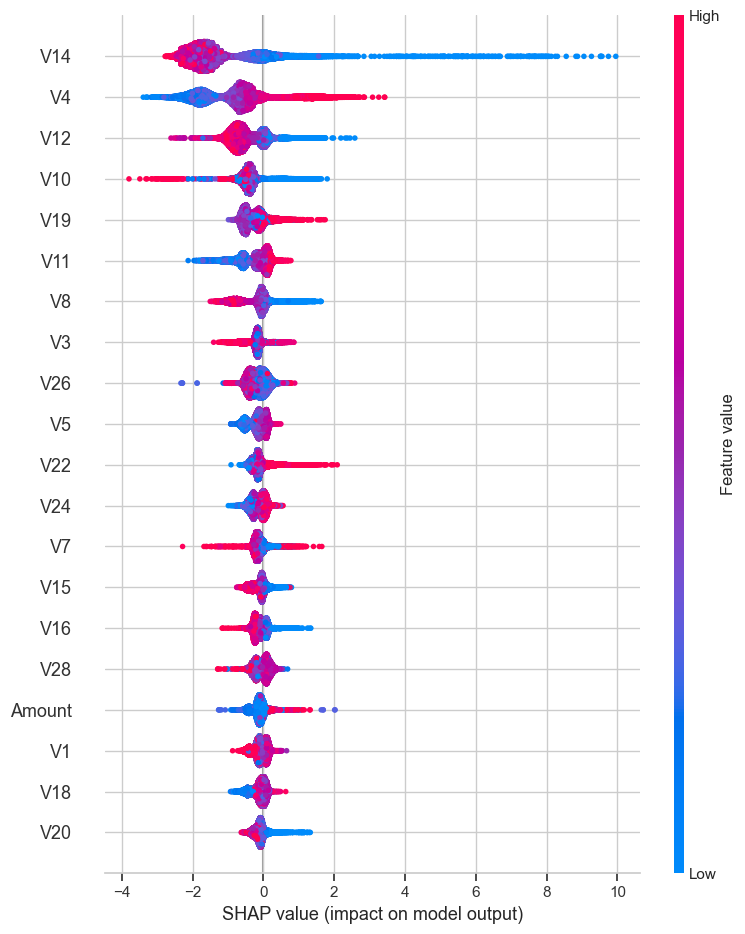

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

**SHAP FORCE PLOT (SINGLE PREDICTION)**

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value,
                shap_values[0],
                X_test.iloc[0])

**CONFUSION MATRIX HEATMAP**

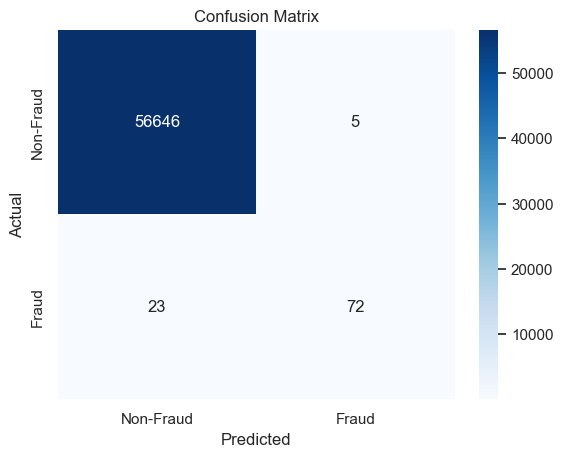

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',   # changed to blue
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**PROBABILITY DISTRIBUTION**

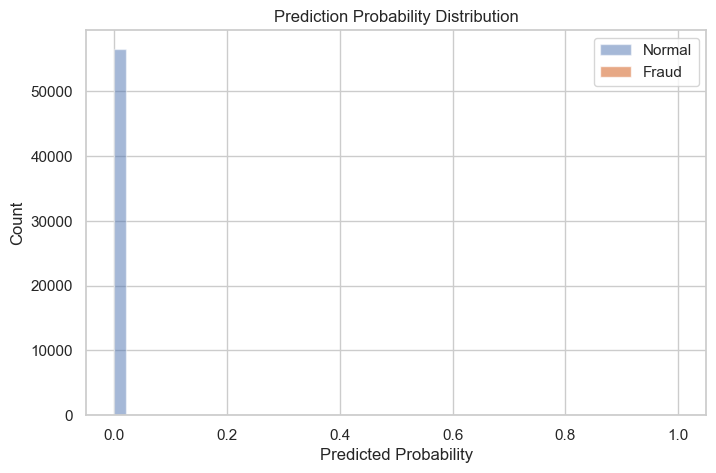

In [ ]:
plt.figure(figsize=(8,5))

# Normal
plt.hist(y_prob[y_test == 0],
         bins=50, alpha=0.5, label="Normal")

# Fraud
plt.hist(y_prob[y_test == 1],
         bins=50, alpha=0.7, label="Fraud")

plt.legend()
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Prediction Probability Distribution")
plt.show()

**TESTING**

SINGLE SAMPLE TESTING

In [ ]:
i = 0  # change index to test different rows

sample = X_test.iloc[i]
actual = y_test.iloc[i]

pred = final_model.predict(sample.values.reshape(1, -1))[0]
prob = final_model.predict_proba(sample.values.reshape(1, -1))[0][1]

# Convert to labels
actual_label = "Fraud" if actual == 1 else "Normal"
pred_label = "Fraud" if pred == 1 else "Normal"

print(" SAMPLE INDEX:", i)
print("--------------------------------------------------")
print(" Actual Value     :", actual, f"({actual_label})")
print(" Predicted Value  :", pred, f"({pred_label})")
print("Fraud Probability:", round(prob, 4))

# Check correctness
if pred == actual:
    print("Result: CORRECT PREDICTION")
else:
    print("Result: WRONG PREDICTION")

 SAMPLE INDEX: 0
--------------------------------------------------
 Actual Value     : 0 (Normal)
 Predicted Value  : 0 (Normal)
Fraud Probability: 0.0
Result: CORRECT PREDICTION


MULTIPLE SAMPLE TESTING

In [ ]:
import pandas as pd

# Number of samples to check
n_samples = 10

results_list = []

for i in range(n_samples):
    
    sample = X_test.iloc[i]
    actual = y_test.iloc[i]
    
    pred = final_model.predict(sample.values.reshape(1, -1))[0]
    prob = final_model.predict_proba(sample.values.reshape(1, -1))[0][1]
    
    results_list.append({
        "Index": i,
        "Actual": "Fraud" if actual == 1 else "Normal",
        "Predicted": "Fraud" if pred == 1 else "Normal",
        "Fraud Probability": round(prob, 4),
        "Result": "Correct" if pred == actual else "Wrong"
    })

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

# Display table
results_df

,Index,Actual,Predicted,Fraud Probability,Result
0,0,Normal,Normal,0.0000,Correct
1,1,Normal,Normal,0.0000,Correct
2,2,Normal,Normal,0.0001,Correct
3,3,Normal,Normal,0.0000,Correct
4,4,Normal,Normal,0.0001,Correct
5,5,Normal,Normal,0.0000,Correct
6,6,Normal,Normal,0.0000,Correct
7,7,Normal,Normal,0.0000,Correct
8,8,Normal,Normal,0.0000,Correct
9,9,Normal,Normal,0.0000,Correct


RANDOM SAMPLES

In [ ]:
import pandas as pd

# Number of random samples
n_samples = 10

# Randomly select indices
random_samples = X_test.sample(n_samples, random_state=42)

results_list = []

for idx, row in random_samples.iterrows():
    
    sample = row.values.reshape(1, -1)
    actual = y_test.loc[idx]
    
    pred = final_model.predict(sample)[0]
    prob = final_model.predict_proba(sample)[0][1]
    
    results_list.append({
        "Index": idx,
        "Actual": "Fraud" if actual == 1 else "Normal",
        "Predicted": "Fraud" if pred == 1 else "Normal",
        "Fraud Probability": round(prob, 4),
        "Result": "Correct" if pred == actual else "Wrong"
    })

# Convert to table
results_df = pd.DataFrame(results_list)

results_df

,Index,Actual,Predicted,Fraud Probability,Result
0,31580,Normal,Normal,0.0000,Correct
1,65974,Normal,Normal,0.0000,Correct
2,268368,Normal,Normal,0.0000,Correct
3,144177,Normal,Normal,0.0000,Correct
4,6323,Normal,Normal,0.0004,Correct
5,279097,Normal,Normal,0.0000,Correct
6,164997,Normal,Normal,0.0000,Correct
7,97193,Normal,Normal,0.0000,Correct
8,132753,Normal,Normal,0.0000,Correct
9,6270,Normal,Normal,0.0000,Correct


“Multiple samples were tested and displayed in tabular format to compare predicted and actual values for model validation.”

In [ ]:
import joblib

joblib.dump(final_model, "fraud_detection_model.pkl")

print(" Model saved successfully!")

 Model saved successfully!


** PROJECT SUMMARY**

This project focuses on detecting fraudulent financial transactions using historical transaction data, with the objective of safeguarding customer assets and minimizing financial losses for organizations. Financial fraud is a critical challenge in the modern digital economy, where fraudulent activities are often hidden within a vast volume of legitimate transactions.

The workflow began with comprehensive data cleaning and preprocessing. Missing values were handled appropriately, inconsistencies were addressed, and irrelevant features were removed to improve data quality. Categorical variables were transformed into numerical representations where necessary, and care was taken to ensure that the dataset was suitable for downstream analysis and modeling.

Exploratory Data Analysis (EDA) was conducted to uncover patterns and distinguishing characteristics of fraudulent transactions. Through statistical analysis and visualizations, it was observed that fraudulent activities tend to exhibit unusual transaction amounts, irregular patterns, and deviations from normal customer behavior. These insights helped in identifying key indicators of fraud and guided feature selection for modeling.

For predictive modeling, classification algorithms such as Logistic Regression and ensemble methods (e.g., Random Forest) were implemented to distinguish between fraudulent and legitimate transactions. Due to the highly imbalanced nature of the dataset, appropriate techniques such as stratified sampling and careful metric selection were applied to ensure reliable model evaluation.

Model performance was evaluated using metrics including accuracy, precision, recall, F1-score, and ROC-AUC, with a strong emphasis on recall. In fraud detection, failing to identify a fraudulent transaction (false negative) can result in significant financial loss, making recall the most critical metric.

The results demonstrated that while simpler models provided baseline performance, ensemble models were more effective in capturing complex patterns associated with fraud. The final model achieved improved recall, making it more reliable in identifying fraudulent transactions.

Furthermore, feature importance analysis highlighted that transaction amount, transaction frequency, time-based patterns, and behavioral anomalies are among the most significant predictors of fraud. These findings align with real-world fraud detection strategies used in financial systems.

Overall, the developed model provides a robust framework for detecting suspicious transactions and can be integrated into real-time monitoring systems. By flagging high-risk transactions, the system enables organizations to take proactive measures, thereby enhancing security, reducing financial losses, and maintaining customer trust.